In [1]:
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

X_feat = np.load("data/X_features.npy")
Y = np.load("data/Y.npy")
feature_names = list(np.load("data/feature_names.npy"))

print(f"Feature matrix: {X_feat.shape}")
print(f"Labels: {Y.shape}, unique: {np.unique(Y)}")


Feature matrix: (1947, 95)
Labels: (1947,), unique: [0 1 2 3]


In [2]:
try:
    subject_ids = np.load("data/subject_ids.npy")
    print(f"Subject IDs loaded: {len(np.unique(subject_ids))} subjects")
    has_subject_ids = True
except FileNotFoundError:
    print("No subject_ids.npy found — using stratified 5-fold as fallback")
    has_subject_ids = False


Subject IDs loaded: 399 subjects


In [3]:
from sklearn.model_selection import StratifiedKFold

label_names = {0: "No Tremor", 1: "Mild", 2: "Moderate", 3: "Severe"}

all_preds = []
all_true = []
all_probs = []

if has_subject_ids:
    subjects = np.unique(subject_ids)
    print(f"Running LOSO across {len(subjects)} subjects")

    for s in subjects:
        test_mask = subject_ids == s
        train_mask = ~test_mask

        X_train, X_test = X_feat[train_mask], X_feat[test_mask]
        y_train, y_test = Y[train_mask], Y[test_mask]

        if len(np.unique(y_train)) < 2:
            continue

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        classes = np.unique(y_train)
        weights = compute_class_weight("balanced", classes=classes, y=y_train)
        class_weight_dict = dict(zip(classes, weights))

        clf = SVC(kernel="rbf", C=10, gamma="scale",
                  class_weight=class_weight_dict, probability=True, random_state=42)
        clf.fit(X_train_s, y_train)

        preds = clf.predict(X_test_s)
        all_preds.extend(preds)
        all_true.extend(y_test)

else:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_feat, Y)):
        X_train, X_test = X_feat[train_idx], X_feat[test_idx]
        y_train, y_test = Y[train_idx], Y[test_idx]

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        classes = np.unique(y_train)
        weights = compute_class_weight("balanced", classes=classes, y=y_train)
        class_weight_dict = dict(zip(classes, weights))

        clf = SVC(kernel="rbf", C=10, gamma="scale",
                  class_weight=class_weight_dict, probability=True, random_state=42)
        clf.fit(X_train_s, y_train)

        preds = clf.predict(X_test_s)
        all_preds.extend(preds)
        all_true.extend(y_test)
        print(f"Fold {fold+1} done")

all_true = np.array(all_true)
all_preds = np.array(all_preds)

print(f"\nTotal predictions: {len(all_preds)}")


Running LOSO across 399 subjects

Total predictions: 1947


In [4]:
acc = accuracy_score(all_true, all_preds)
macro_f1 = f1_score(all_true, all_preds, average="macro")
weighted_f1 = f1_score(all_true, all_preds, average="weighted")

print("=" * 50)
print(f"Overall Accuracy : {acc*100:.2f}%")
print(f"Macro F1         : {macro_f1:.4f}")
print(f"Weighted F1      : {weighted_f1:.4f}")
print("=" * 50)

present_labels = sorted(np.unique(all_true))
target_names = [label_names[l] for l in present_labels]
print(classification_report(all_true, all_preds,
                             labels=present_labels,
                             target_names=target_names))

np.save("data/all_true.npy", all_true)
np.save("data/all_preds.npy", all_preds)


Overall Accuracy : 90.91%
Macro F1         : 0.4307
Weighted F1      : 0.9082
              precision    recall  f1-score   support

   No Tremor       0.96      0.96      0.96      1791
        Mild       0.19      0.21      0.20        47
    Moderate       0.49      0.52      0.51        87
      Severe       0.10      0.05      0.06        22

    accuracy                           0.91      1947
   macro avg       0.43      0.43      0.43      1947
weighted avg       0.91      0.91      0.91      1947



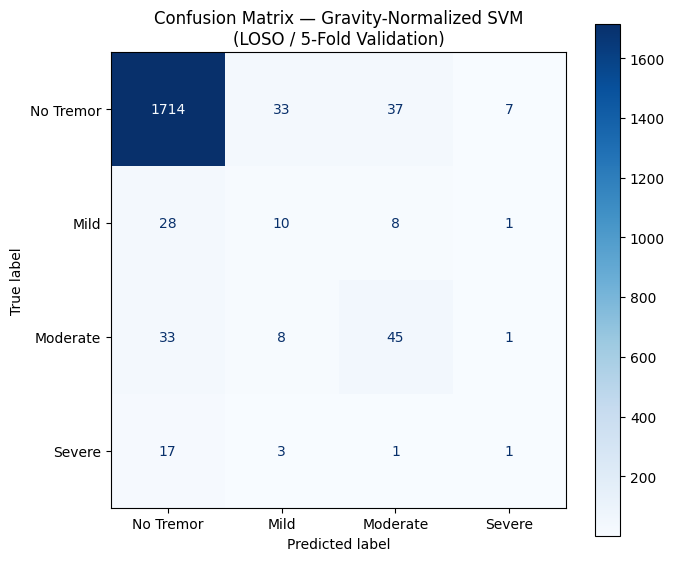

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay

present_labels = sorted(np.unique(all_true))
target_names = [label_names[l] for l in present_labels]

cm = confusion_matrix(all_true, all_preds, labels=present_labels)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — Gravity-Normalized SVM\n(LOSO / 5-Fold Validation)", fontsize=12)
plt.tight_layout()
plt.savefig("figures/03_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


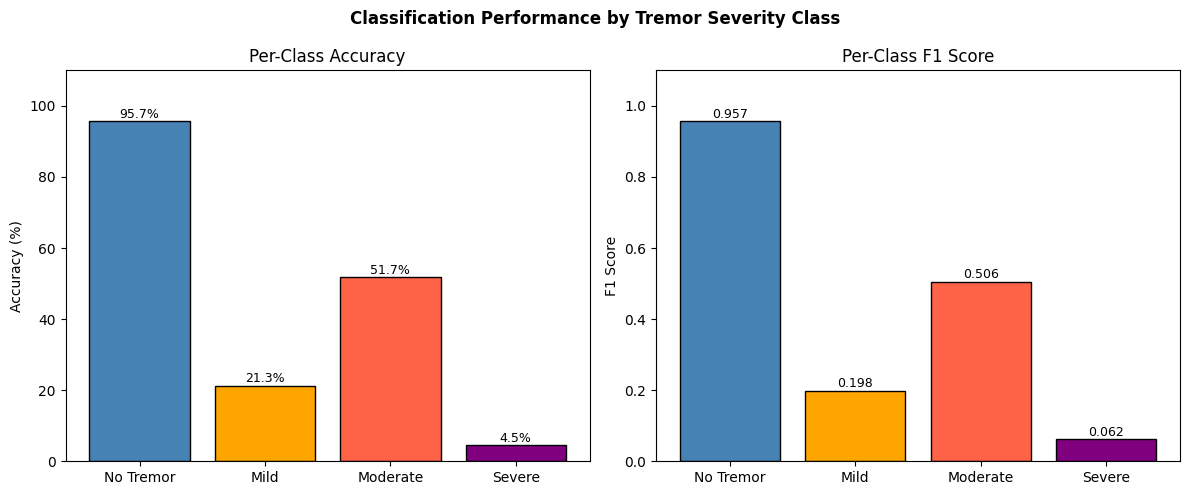

In [6]:
per_class_acc = []
per_class_f1 = []

for cls in present_labels:
    mask = all_true == cls
    if mask.sum() == 0:
        continue
    cls_acc = accuracy_score(all_true[mask], all_preds[mask])
    per_class_acc.append(cls_acc)
    cls_f1 = f1_score(all_true == cls, all_preds == cls)
    per_class_f1.append(cls_f1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["steelblue", "orange", "tomato", "purple"][:len(present_labels)]
names = [label_names[l] for l in present_labels]

bars1 = axes[0].bar(names, [a*100 for a in per_class_acc], color=colors, edgecolor="black")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Per-Class Accuracy")
axes[0].set_ylim(0, 110)
for bar, v in zip(bars1, per_class_acc):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{v*100:.1f}%", ha="center", fontsize=9)

bars2 = axes[1].bar(names, per_class_f1, color=colors, edgecolor="black")
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Per-Class F1 Score")
axes[1].set_ylim(0, 1.1)
for bar, v in zip(bars2, per_class_f1):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{v:.3f}", ha="center", fontsize=9)

plt.suptitle("Classification Performance by Tremor Severity Class", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/03_per_class_performance.png", dpi=150, bbox_inches="tight")
plt.show()
